In [1]:
# =====================================================================
# 02_exploratory_analysis.ipynb
# Historical Time Series Analysis of Air Raid Alerts in Ukraine
# Step 2: Exploratory Data Analysis
# =====================================================================

from pathlib import Path
import sys
import importlib

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ---------------------------------------------------------------------
# 1. Find project root and src/
# ---------------------------------------------------------------------

current_dir = Path.cwd().resolve()

if (current_dir / "src").exists():
    PROJECT_ROOT = current_dir

elif (current_dir.parent / "src").exists():
    PROJECT_ROOT = current_dir.parent

else:
    raise FileNotFoundError(
        "Project root was not found.\n"
        "Expected a folder named 'src' in the current directory "
        "or its parent directory.\n"
        f"Current working directory: {current_dir}"
    )

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


# ---------------------------------------------------------------------
# 2. Load the newest config.py version
# ---------------------------------------------------------------------

if "config" in sys.modules:
    del sys.modules["config"]

importlib.invalidate_caches()

import config

print("=" * 78)
print("CONFIG CHECK")
print("=" * 78)

print(f"Loaded config module from: {config.__file__}")

DAILY_REGION_METRICS_FILE = config.DAILY_REGION_METRICS_FILE
FIGURES_DIR = config.FIGURES_DIR
SELECTED_REGIONS = config.SELECTED_REGIONS
FORECAST_REGION = config.FORECAST_REGION


# ---------------------------------------------------------------------
# 3. Load daily aggregated metrics
# ---------------------------------------------------------------------

print("\n" + "=" * 78)
print("DAILY METRICS LOADING")
print("=" * 78)

print(f"Expected file path: {DAILY_REGION_METRICS_FILE}")

if not DAILY_REGION_METRICS_FILE.exists():
    raise FileNotFoundError(
        "The daily metrics CSV was not found.\n"
        "Run the daily aggregation cell in 01_data_audit.ipynb first.\n\n"
        f"Expected file: {DAILY_REGION_METRICS_FILE}"
    )

daily_metrics = pd.read_csv(
    DAILY_REGION_METRICS_FILE,
    parse_dates=["date"],
)

print("✅ Daily metrics loaded successfully.")
print(f"Shape: {daily_metrics.shape[0]:,} rows × {daily_metrics.shape[1]} columns")

print("\nColumns:")
print(daily_metrics.columns.tolist())

print("\nFirst 5 rows:")
display(daily_metrics.head())


# ---------------------------------------------------------------------
# 4. Basic validation
# ---------------------------------------------------------------------

required_columns = [
    "date",
    "region",
    "alert_start_count",
    "active_alert_count",
    "total_duration_min",
    "mean_active_duration_min",
]

missing_columns = [
    column
    for column in required_columns
    if column not in daily_metrics.columns
]

if missing_columns:
    raise KeyError(
        "The daily metrics file is missing required columns:\n"
        f"{missing_columns}"
    )

available_regions = sorted(daily_metrics["region"].unique())

missing_selected_regions = [
    region
    for region in SELECTED_REGIONS
    if region not in available_regions
]

print("\n" + "=" * 78)
print("SELECTED REGIONS CHECK")
print("=" * 78)

print("Regions from config.py:")
for region in SELECTED_REGIONS:
    print(f"  - {region}")

if missing_selected_regions:
    print("\n⚠️ These configured regions were not found:")
    for region in missing_selected_regions:
        print(f"  - {region}")

    print("\nAvailable regions:")
    for region in available_regions:
        print(f"  - {region}")

        print("\nConfigured regions:")
print(SELECTED_REGIONS)

print("\nAvailable regions:")
print(available_regions)

print("\nMissing regions:")
print(missing_selected_regions)


    # raise ValueError(
    #     "Update SELECTED_REGIONS in src/config.py "
    #     "using the exact region names from the dataset."
    # )

print("\n✅ All selected regions exist in the daily metrics dataset.")

CONFIG CHECK
Loaded config module from: D:\it10\PythonProject2\src\config.py

DAILY METRICS LOADING
Expected file path: D:\it10\PythonProject2\data\processed\daily_region_metrics.csv
✅ Daily metrics loaded successfully.
Shape: 33,925 rows × 6 columns

Columns:
['date', 'region', 'total_duration_min', 'active_alert_count', 'alert_start_count', 'mean_active_duration_min']

First 5 rows:


,date,region,total_duration_min,active_alert_count,alert_start_count,mean_active_duration_min
0,2022-03-15,Cherkaska oblast,0.000000,0,0,0.000000
1,2022-03-16,Cherkaska oblast,232.333333,1,1,232.333333
2,2022-03-17,Cherkaska oblast,97.266667,2,2,48.633333
3,2022-03-18,Cherkaska oblast,83.900000,2,2,41.950000
4,2022-03-19,Cherkaska oblast,51.450000,1,1,51.450000



SELECTED REGIONS CHECK
Regions from config.py:
  - Kyiv City
  - Lvivska oblast
  - Odeska oblast
  - Kharkivska oblast
  - Dnipropetrovska oblast
['Kyiv City', 'Lvivska oblast', 'Odeska oblast', 'Kharkivska oblast', 'Dnipropetrovska oblast']

Available regions:
['Cherkaska oblast', 'Chernihivska oblast', 'Chernivetska oblast', 'Dnipropetrovska oblast', 'Donetska oblast', 'Ivano-Frankivska oblast', 'Kharkivska oblast', 'Khersonska oblast', 'Khmelnytska oblast', 'Kirovohradska oblast', 'Kyiv City', 'Kyivska oblast', 'Luhanska oblast', 'Lvivska oblast', 'Mykolaivska oblast', 'Odeska oblast', 'Poltavska oblast', 'Rivnenska oblast', 'Sumska oblast', 'Ternopilska oblast', 'Vinnytska oblast', 'Volynska oblast', 'Zakarpatska oblast', 'Zaporizka oblast', 'Zhytomyrska oblast']

Missing regions:
[]

✅ All selected regions exist in the daily metrics dataset.


SELECTED DAILY METRICS
Rows for selected regions: 6,785
Regions included: 5


,region,first_date,last_date,total_days,total_alert_hours
1,Kharkivska oblast,2022-03-15,2025-11-30,1357,9105.549444
0,Dnipropetrovska oblast,2022-03-15,2025-11-30,1357,5399.886944
4,Odeska oblast,2022-03-15,2025-11-30,1357,2392.721111
2,Kyiv City,2022-03-15,2025-11-30,1357,2180.618889
3,Lvivska oblast,2022-03-15,2025-11-30,1357,811.355833



MONTHLY AGGREGATED DATA PREVIEW


,month,region,total_duration_min,alert_start_count,total_duration_hours
0,2022-03-01,Dnipropetrovska oblast,2923.350000,45,48.722500
1,2022-03-01,Kharkivska oblast,6162.016667,93,102.700278
2,2022-03-01,Kyiv City,7524.300000,102,125.405000
3,2022-03-01,Lvivska oblast,2009.850000,31,33.497500
4,2022-03-01,Odeska oblast,1872.133333,34,31.202222
5,2022-04-01,Dnipropetrovska oblast,6599.250000,150,109.987500
6,2022-04-01,Kharkivska oblast,9616.333333,184,160.272222
7,2022-04-01,Kyiv City,4146.633333,73,69.110556
8,2022-04-01,Lvivska oblast,2520.750000,42,42.012500
9,2022-04-01,Odeska oblast,3177.583333,57,52.959722


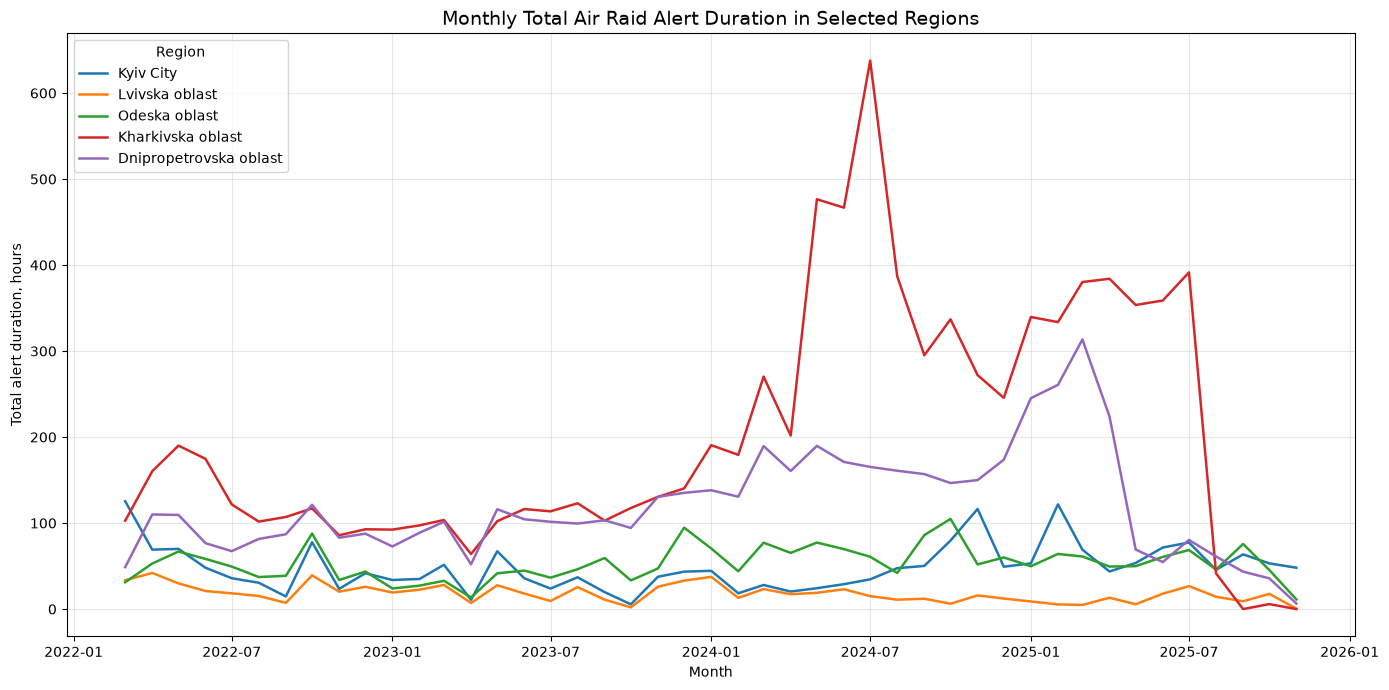


✅ Figure saved successfully:
D:\it10\PythonProject2\reports\figures\01_monthly_alert_hours_selected_regions.png


In [2]:
# =====================================================================
# Monthly total alert duration for selected regions
# =====================================================================

# ---------------------------------------------------------------------
# 1. Select five regions for comparison
# ---------------------------------------------------------------------

selected_daily_metrics = (
    daily_metrics.loc[
        daily_metrics["region"].isin(SELECTED_REGIONS)
    ]
    .copy()
)

if selected_daily_metrics.empty:
    raise ValueError(
        "No records were found for selected regions."
    )

print("=" * 78)
print("SELECTED DAILY METRICS")
print("=" * 78)

print(f"Rows for selected regions: {len(selected_daily_metrics):,}")
print(f"Regions included: {selected_daily_metrics['region'].nunique()}")

display(
    selected_daily_metrics
    .groupby("region", as_index=False)
    .agg(
        first_date=("date", "min"),
        last_date=("date", "max"),
        total_days=("date", "count"),
        total_alert_hours=(
            "total_duration_min",
            lambda values: values.sum() / 60,
        ),
    )
    .sort_values("total_alert_hours", ascending=False)
)


# ---------------------------------------------------------------------
# 2. Aggregate daily minutes into monthly total hours
# ---------------------------------------------------------------------

monthly_duration = (
    selected_daily_metrics
    .assign(
        month=lambda dataframe: (
            dataframe["date"]
            .dt.to_period("M")
            .dt.to_timestamp()
        )
    )
    .groupby(
        ["month", "region"],
        as_index=False,
    )
    .agg(
        total_duration_min=(
            "total_duration_min",
            "sum",
        ),
        alert_start_count=(
            "alert_start_count",
            "sum",
        ),
    )
)

monthly_duration["total_duration_hours"] = (
    monthly_duration["total_duration_min"] / 60
)

print("\n" + "=" * 78)
print("MONTHLY AGGREGATED DATA PREVIEW")
print("=" * 78)

display(monthly_duration.head(15))


# ---------------------------------------------------------------------
# 3. Create the line plot
# ---------------------------------------------------------------------

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

figure_path = (
    FIGURES_DIR
    / "01_monthly_alert_hours_selected_regions.png"
)

plt.figure(figsize=(14, 7))

for region in SELECTED_REGIONS:
    region_monthly_data = (
        monthly_duration.loc[
            monthly_duration["region"].eq(region)
        ]
        .sort_values("month")
    )

    plt.plot(
        region_monthly_data["month"],
        region_monthly_data["total_duration_hours"],
        label=region,
        linewidth=1.8,
    )

plt.title(
    "Monthly Total Air Raid Alert Duration in Selected Regions",
    fontsize=14,
)

plt.xlabel("Month")
plt.ylabel("Total alert duration, hours")

plt.grid(
    True,
    alpha=0.3,
)

plt.legend(
    title="Region",
    loc="upper left",
)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("\n✅ Figure saved successfully:")
print(figure_path)

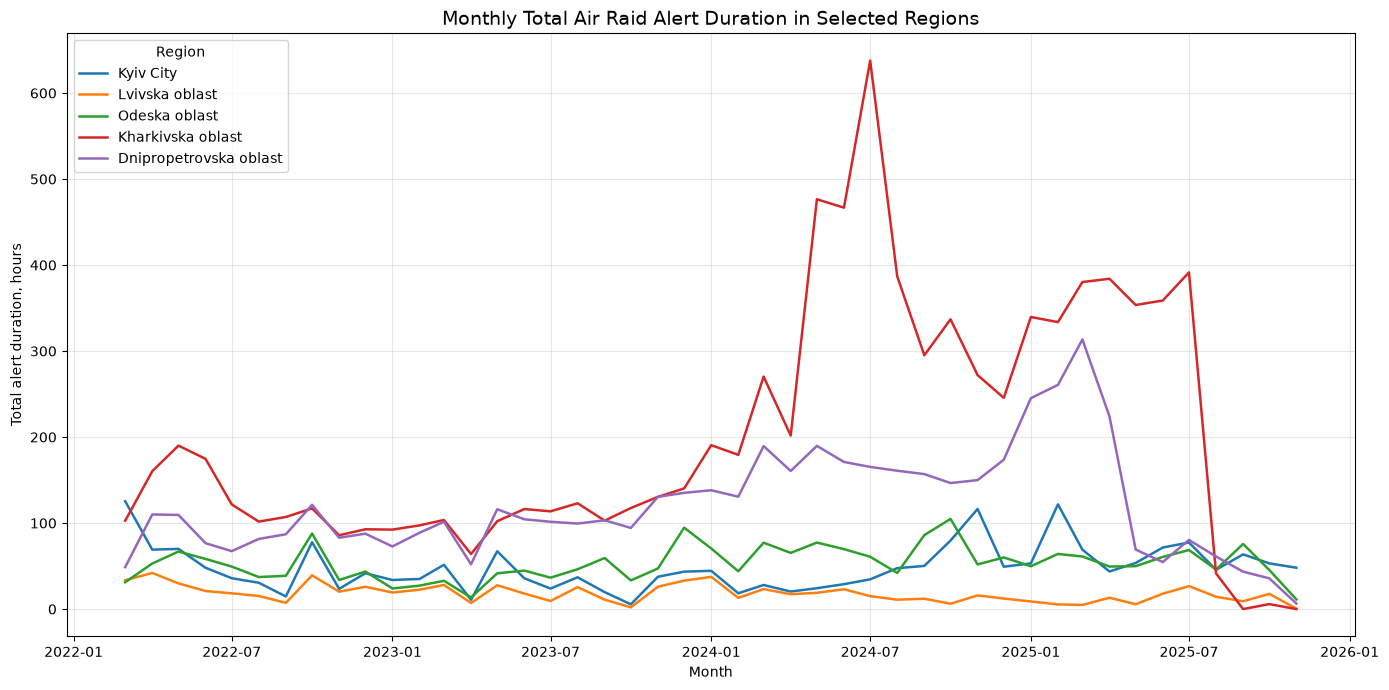

REUSABLE MONTHLY VISUALIZATION RESULT
Monthly rows: 225
Regions in monthly table: 5
Month range: 2022-03-01 to 2025-11-01

Monthly aggregation preview:


,month,region,total_duration_min,alert_start_count,total_duration_hours
0,2022-03-01,Dnipropetrovska oblast,2923.350000,45,48.722500
1,2022-04-01,Dnipropetrovska oblast,6599.250000,150,109.987500
2,2022-05-01,Dnipropetrovska oblast,6569.400000,115,109.490000
3,2022-06-01,Dnipropetrovska oblast,4596.166667,93,76.602778
4,2022-07-01,Dnipropetrovska oblast,4040.366667,99,67.339444
5,2022-08-01,Dnipropetrovska oblast,4893.133333,148,81.552222
6,2022-09-01,Dnipropetrovska oblast,5219.983333,157,86.999722
7,2022-10-01,Dnipropetrovska oblast,7271.700000,128,121.195000
8,2022-11-01,Dnipropetrovska oblast,4976.966667,96,82.949444
9,2022-12-01,Dnipropetrovska oblast,5260.283333,101,87.671389



Files created:
  D:\it10\PythonProject2\reports\figures\01_monthly_alert_hours_selected_regions.png
  D:\it10\PythonProject2\data\processed\monthly_duration_selected_regions.csv

✅ Reusable monthly aggregation and plotting work correctly.


In [3]:
# =====================================================================
# Reusable monthly aggregation and plotting script
# =====================================================================

import importlib

import config
import visualization

importlib.reload(config)
importlib.reload(visualization)

from visualization import (
    plot_monthly_total_alert_duration,
    prepare_monthly_duration,
)


# ---------------------------------------------------------------------
# Refresh settings from config.py
# ---------------------------------------------------------------------

SELECTED_REGIONS = config.SELECTED_REGIONS
FIGURES_DIR = config.FIGURES_DIR
PROCESSED_DATA_DIR = config.PROCESSED_DATA_DIR

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------------------
# Create reusable monthly aggregation
# ---------------------------------------------------------------------

monthly_duration_script = prepare_monthly_duration(
    daily_metrics=daily_metrics,
    selected_regions=SELECTED_REGIONS,
)

monthly_table_path = (
    PROCESSED_DATA_DIR
    / "monthly_duration_selected_regions.csv"
)

monthly_duration_script.to_csv(
    monthly_table_path,
    index=False,
)


# ---------------------------------------------------------------------
# Create reusable figure
# ---------------------------------------------------------------------

figure_path = (
    FIGURES_DIR
    / "01_monthly_alert_hours_selected_regions.png"
)

figure, axes = plot_monthly_total_alert_duration(
    monthly_duration=monthly_duration_script,
    selected_regions=SELECTED_REGIONS,
    output_path=figure_path,
)

plt.show()


# ---------------------------------------------------------------------
# Validation and output
# ---------------------------------------------------------------------

print("=" * 78)
print("REUSABLE MONTHLY VISUALIZATION RESULT")
print("=" * 78)

print(f"Monthly rows: {len(monthly_duration_script):,}")
print(
    f"Regions in monthly table: "
    f"{monthly_duration_script['region'].nunique()}"
)

print(
    f"Month range: "
    f"{monthly_duration_script['month'].min().date()} "
    f"to {monthly_duration_script['month'].max().date()}"
)

print("\nMonthly aggregation preview:")
display(monthly_duration_script.head(15))

assert set(
    monthly_duration_script["region"].unique()
) == set(SELECTED_REGIONS)

assert (
    monthly_duration_script["total_duration_hours"] >= 0
).all()

assert figure_path.exists()
assert monthly_table_path.exists()

print("\nFiles created:")
print(f"  {figure_path}")
print(f"  {monthly_table_path}")

print("\n✅ Reusable monthly aggregation and plotting work correctly.")

TOP 10 REGIONS BY TOTAL ALERT DURATION


,region,total_duration_min,total_duration_hours,total_duration_days,total_alert_starts,total_active_alert_days
0,Khersonska oblast,226898.666667,3781.644444,157.568519,3575,1114
1,Kirovohradska oblast,232226.083333,3870.434722,161.268113,3344,1177
2,Mykolaivska oblast,252079.366667,4201.322778,175.055116,3681,1231
3,Chernihivska oblast,260672.166667,4344.536111,181.022338,2513,1047
4,Poltavska oblast,314692.350000,5244.872500,218.536354,3993,1189
5,Dnipropetrovska oblast,323993.216667,5399.886944,224.995289,5565,1289
6,Zaporizka oblast,439116.416667,7318.606944,304.941956,6686,1323
7,Sumska oblast,478789.983333,7979.833056,332.493044,4078,1169
8,Kharkivska oblast,546332.966667,9105.549444,379.397894,6504,1249
9,Donetska oblast,738147.950000,12302.465833,512.602743,6877,1312


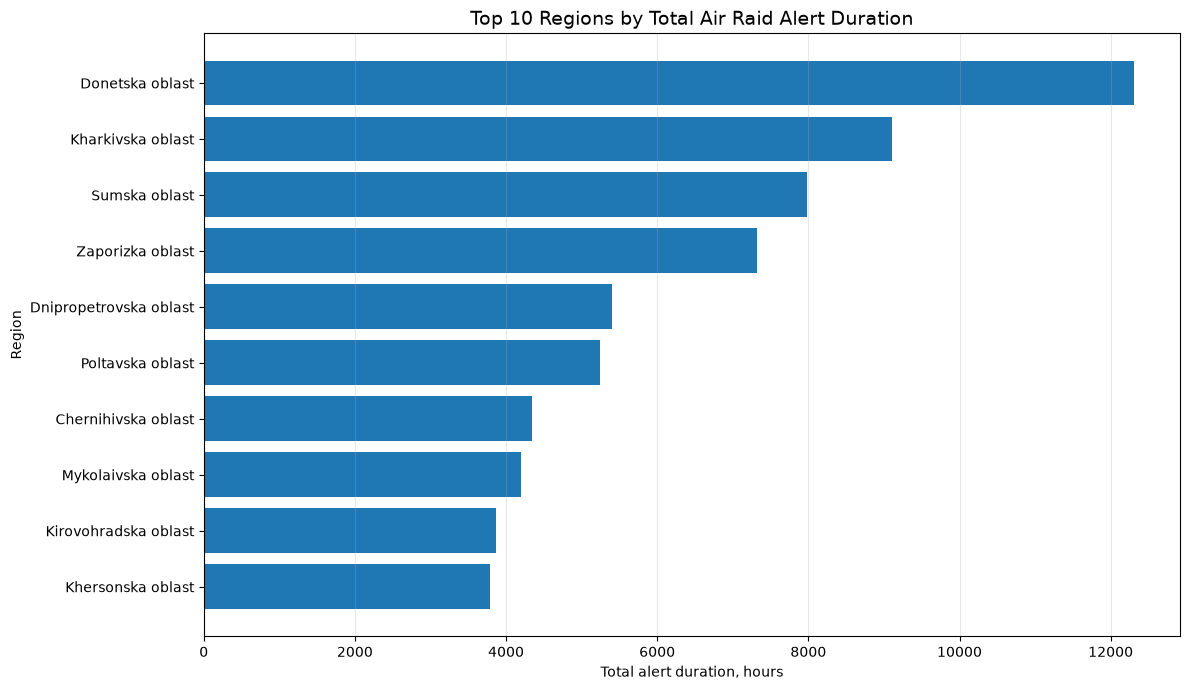


✅ Figure saved successfully:
D:\it10\PythonProject2\reports\figures\02_top_regions_total_duration.png

✅ Top-10 regional comparison was created successfully.


In [4]:
# =====================================================================
# Top 10 regions by total air raid alert duration
# =====================================================================

# ---------------------------------------------------------------------
# 1. Aggregate total duration for the entire analysis period
# ---------------------------------------------------------------------

region_total_duration = (
    daily_metrics
    .groupby(
        "region",
        as_index=False,
    )
    .agg(
        total_duration_min=(
            "total_duration_min",
            "sum",
        ),
        total_alert_starts=(
            "alert_start_count",
            "sum",
        ),
        total_active_alert_days=(
            "active_alert_count",
            lambda values: (values > 0).sum(),
        ),
    )
)

region_total_duration["total_duration_hours"] = (
    region_total_duration["total_duration_min"] / 60
)

region_total_duration["total_duration_days"] = (
    region_total_duration["total_duration_hours"] / 24
)

top_10_regions = (
    region_total_duration
    .sort_values(
        by="total_duration_hours",
        ascending=False,
    )
    .head(10)
    .sort_values(
        by="total_duration_hours",
        ascending=True,
    )
    .reset_index(drop=True)
)

print("=" * 78)
print("TOP 10 REGIONS BY TOTAL ALERT DURATION")
print("=" * 78)

display(
    top_10_regions[
        [
            "region",
            "total_duration_min",
            "total_duration_hours",
            "total_duration_days",
            "total_alert_starts",
            "total_active_alert_days",
        ]
    ]
)


# ---------------------------------------------------------------------
# 2. Create horizontal bar chart
# ---------------------------------------------------------------------

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

figure_path = (
    FIGURES_DIR
    / "02_top_regions_total_duration.png"
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_10_regions["region"],
    top_10_regions["total_duration_hours"],
)

plt.title(
    "Top 10 Regions by Total Air Raid Alert Duration",
    fontsize=14,
)

plt.xlabel("Total alert duration, hours")
plt.ylabel("Region")

plt.grid(
    axis="x",
    alpha=0.3,
)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("\n✅ Figure saved successfully:")
print(figure_path)


# ---------------------------------------------------------------------
# 3. Basic checks
# ---------------------------------------------------------------------

assert len(top_10_regions) == 10
assert top_10_regions["region"].nunique() == 10
assert (
    top_10_regions["total_duration_hours"] >= 0
).all()

assert figure_path.exists()

print("\n✅ Top-10 regional comparison was created successfully.")

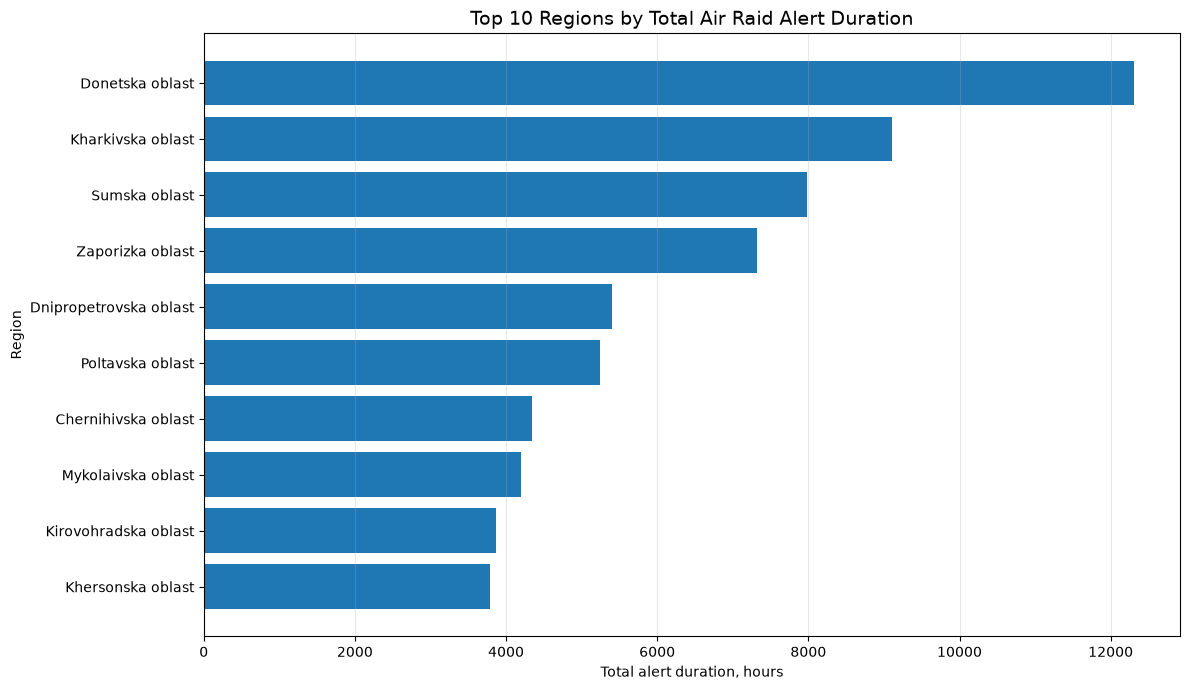

REUSABLE TOP-10 REGIONAL RANKING RESULT
Rows in complete regional summary: 25
Rows in top-10 table: 10

Top-10 regions:


,region,total_duration_min,total_alert_starts,total_active_alert_days,total_duration_hours,total_duration_days
0,Khersonska oblast,226898.666667,3575,1114,3781.644444,157.568519
1,Kirovohradska oblast,232226.083333,3344,1177,3870.434722,161.268113
2,Mykolaivska oblast,252079.366667,3681,1231,4201.322778,175.055116
3,Chernihivska oblast,260672.166667,2513,1047,4344.536111,181.022338
4,Poltavska oblast,314692.350000,3993,1189,5244.872500,218.536354
5,Dnipropetrovska oblast,323993.216667,5565,1289,5399.886944,224.995289
6,Zaporizka oblast,439116.416667,6686,1323,7318.606944,304.941956
7,Sumska oblast,478789.983333,4078,1169,7979.833056,332.493044
8,Kharkivska oblast,546332.966667,6504,1249,9105.549444,379.397894
9,Donetska oblast,738147.950000,6877,1312,12302.465833,512.602743



Files created:
  D:\it10\PythonProject2\data\processed\region_total_duration.csv
  D:\it10\PythonProject2\data\processed\top_10_regions_total_duration.csv
  D:\it10\PythonProject2\reports\figures\02_top_regions_total_duration.png

✅ Reusable top-10 regional ranking works correctly.


In [9]:
# =====================================================================
# Reusable top-10 regional ranking and plot
# =====================================================================

import importlib

import config
import visualization

importlib.reload(config)
importlib.reload(visualization)

from visualization import (
    plot_top_regions_by_total_duration,
    prepare_top_regions_by_total_duration,
)


# ---------------------------------------------------------------------
# Create ranking table with reusable function
# ---------------------------------------------------------------------

top_regions_script = prepare_top_regions_by_total_duration(
    daily_metrics=daily_metrics,
    top_n=10,
)

regional_summary_path = (
    config.PROCESSED_DATA_DIR
    / "region_total_duration.csv"
)

top_regions_path = (
    config.PROCESSED_DATA_DIR
    / "top_10_regions_total_duration.csv"
)

top_regions_figure_path = (
    config.FIGURES_DIR
    / "02_top_regions_total_duration.png"
)

config.PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

config.FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------------------
# Save full regional summary and top-10 table
# ---------------------------------------------------------------------

full_region_summary = (
    daily_metrics
    .groupby(
        "region",
        as_index=False,
    )
    .agg(
        total_duration_min=(
            "total_duration_min",
            "sum",
        ),
        total_alert_starts=(
            "alert_start_count",
            "sum",
        ),
        total_active_alert_days=(
            "active_alert_count",
            lambda values: (values > 0).sum(),
        ),
    )
)

full_region_summary["total_duration_hours"] = (
    full_region_summary["total_duration_min"] / 60
)

full_region_summary["total_duration_days"] = (
    full_region_summary["total_duration_hours"] / 24
)

full_region_summary = full_region_summary.sort_values(
    "total_duration_hours",
    ascending=False,
).reset_index(drop=True)

full_region_summary.to_csv(
    regional_summary_path,
    index=False,
)

top_regions_script.to_csv(
    top_regions_path,
    index=False,
)


# ---------------------------------------------------------------------
# Create figure
# ---------------------------------------------------------------------

figure, axes = plot_top_regions_by_total_duration(
    top_regions=top_regions_script,
    output_path=top_regions_figure_path,
)

plt.show()


# ---------------------------------------------------------------------
# Validation and output
# ---------------------------------------------------------------------

print("=" * 78)
print("REUSABLE TOP-10 REGIONAL RANKING RESULT")
print("=" * 78)

print(f"Rows in complete regional summary: {len(full_region_summary):,}")
print(f"Rows in top-10 table: {len(top_regions_script):,}")

print("\nTop-10 regions:")
display(top_regions_script)

assert len(full_region_summary) == 25
assert len(top_regions_script) == 10
assert top_regions_script["region"].nunique() == 10
assert (
    top_regions_script["total_duration_hours"]
    .is_monotonic_increasing
)

assert regional_summary_path.exists()
assert top_regions_path.exists()
assert top_regions_figure_path.exists()

print("\nFiles created:")
print(f"  {regional_summary_path}")
print(f"  {top_regions_path}")
print(f"  {top_regions_figure_path}")

print("\n✅ Reusable top-10 regional ranking works correctly.")

CLEANED EVENT DATA LOADING
Expected cleaned dataset path: D:\it10\PythonProject2\data\processed\alerts_cleaned.csv
✅ Cleaned event-level dataset loaded successfully.
Shape: 64,842 rows × 10 columns

SELECTED EVENT DATA CHECK
Event rows for selected regions: 17,020
Regions included: 5


,region,event_count,min_duration_min,max_duration_min
0,Dnipropetrovska oblast,5565,0.050000,774.450000
1,Kharkivska oblast,6504,0.033333,3031.300000
2,Kyiv City,1795,0.766667,631.383333
3,Lvivska oblast,745,0.916667,334.100000
4,Odeska oblast,2411,0.133333,1352.550000



INDIVIDUAL ALERT DURATION SUMMARY


,region,event_count,mean_duration_min,median_duration_min,p25_duration_min,p75_duration_min,p95_duration_min,max_duration_min
0,Kyiv City,1795,72.89,39.97,24.72,89.37,238.66,631.38
1,Lvivska oblast,745,65.34,44.82,26.65,90.63,169.06,334.10
2,Odeska oblast,2411,59.55,35.30,22.40,74.87,180.04,1352.55
3,Kharkivska oblast,6504,84.00,40.68,27.76,86.51,307.10,3031.30
4,Dnipropetrovska oblast,5565,58.22,33.12,23.57,58.55,194.31,774.45


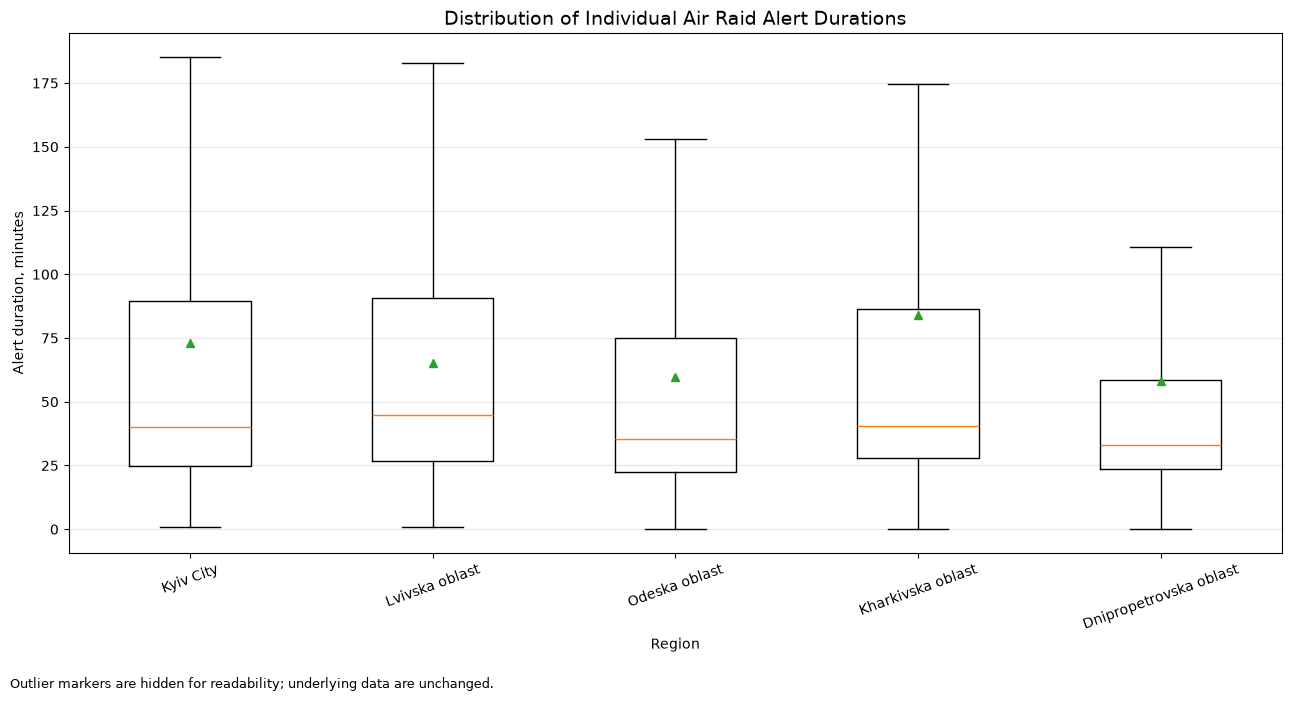


✅ Figure saved successfully:
D:\it10\PythonProject2\reports\figures\03_alert_duration_distribution.png

✅ Individual alert duration distribution was created successfully.


In [8]:
# =====================================================================
# Distribution of individual alert durations in selected regions
# =====================================================================

import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import config

importlib.reload(config)

CLEANED_ALERTS_FILE = config.CLEANED_ALERTS_FILE
FIGURES_DIR = config.FIGURES_DIR
SELECTED_REGIONS = config.SELECTED_REGIONS


# ---------------------------------------------------------------------
# 1. Load cleaned event-level data
# ---------------------------------------------------------------------

print("=" * 78)
print("CLEANED EVENT DATA LOADING")
print("=" * 78)

print(f"Expected cleaned dataset path: {CLEANED_ALERTS_FILE}")

if not CLEANED_ALERTS_FILE.exists():
    raise FileNotFoundError(
        "The cleaned event-level CSV was not found.\n"
        "Return to 01_data_audit.ipynb and run the cell that saves "
        "df_cleaned to alerts_cleaned.csv.\n\n"
        f"Expected file: {CLEANED_ALERTS_FILE}"
    )

cleaned_events = pd.read_csv(CLEANED_ALERTS_FILE)

print("✅ Cleaned event-level dataset loaded successfully.")
print(
    f"Shape: {cleaned_events.shape[0]:,} rows × "
    f"{cleaned_events.shape[1]} columns"
)


# ---------------------------------------------------------------------
# 2. Validate source columns and selected regions
# ---------------------------------------------------------------------

required_columns = [
    "region",
    "duration_min",
]

missing_columns = [
    column
    for column in required_columns
    if column not in cleaned_events.columns
]

if missing_columns:
    raise KeyError(
        "The cleaned event-level dataset is missing required columns:\n"
        f"{missing_columns}\n\n"
        f"Available columns:\n{cleaned_events.columns.tolist()}"
    )

available_regions = sorted(
    cleaned_events["region"]
    .dropna()
    .unique()
)

missing_selected_regions = [
    region
    for region in SELECTED_REGIONS
    if region not in available_regions
]

if missing_selected_regions:
    raise ValueError(
        "Some selected regions were not found in cleaned event data:\n"
        f"{missing_selected_regions}"
    )

selected_events = (
    cleaned_events.loc[
        cleaned_events["region"].isin(SELECTED_REGIONS),
        ["region", "duration_min"],
    ]
    .copy()
)

if selected_events.empty:
    raise ValueError(
        "No cleaned events were found for selected regions."
    )

if not (selected_events["duration_min"] > 0).all():
    raise ValueError(
        "Non-positive alert durations were found in selected events."
    )

print("\n" + "=" * 78)
print("SELECTED EVENT DATA CHECK")
print("=" * 78)

print(f"Event rows for selected regions: {len(selected_events):,}")
print(f"Regions included: {selected_events['region'].nunique()}")

display(
    selected_events
    .groupby("region", as_index=False)
    .agg(
        event_count=("duration_min", "count"),
        min_duration_min=("duration_min", "min"),
        max_duration_min=("duration_min", "max"),
    )
    .sort_values("region")
)


# ---------------------------------------------------------------------
# 3. Build summary statistics for interpretation
# ---------------------------------------------------------------------

duration_summary = (
    selected_events
    .groupby("region", as_index=False)
    .agg(
        event_count=("duration_min", "count"),
        mean_duration_min=("duration_min", "mean"),
        median_duration_min=("duration_min", "median"),
        p25_duration_min=(
            "duration_min",
            lambda values: values.quantile(0.25),
        ),
        p75_duration_min=(
            "duration_min",
            lambda values: values.quantile(0.75),
        ),
        p95_duration_min=(
            "duration_min",
            lambda values: values.quantile(0.95),
        ),
        max_duration_min=("duration_min", "max"),
    )
)

duration_summary = (
    duration_summary
    .set_index("region")
    .reindex(SELECTED_REGIONS)
    .reset_index()
)

print("\n" + "=" * 78)
print("INDIVIDUAL ALERT DURATION SUMMARY")
print("=" * 78)

display(duration_summary.round(2))


# ---------------------------------------------------------------------
# 4. Prepare data for a boxplot
# ---------------------------------------------------------------------

boxplot_data = [
    selected_events.loc[
        selected_events["region"].eq(region),
        "duration_min",
    ].to_numpy()
    for region in SELECTED_REGIONS
]

if any(len(values) == 0 for values in boxplot_data):
    raise ValueError(
        "At least one selected region has no event durations."
    )


# ---------------------------------------------------------------------
# 5. Create boxplot
# ---------------------------------------------------------------------

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

figure_path = (
    FIGURES_DIR
    / "03_alert_duration_distribution.png"
)

figure, axes = plt.subplots(figsize=(13, 7))

axes.boxplot(
    boxplot_data,
    tick_labels=SELECTED_REGIONS,
    showfliers=False,
    showmeans=True,
)

axes.set_title(
    "Distribution of Individual Air Raid Alert Durations",
    fontsize=14,
)

axes.set_xlabel("Region")
axes.set_ylabel("Alert duration, minutes")

axes.grid(
    axis="y",
    alpha=0.3,
)

axes.tick_params(
    axis="x",
    rotation=20,
)

figure.text(
    0.01,
    0.01,
    "Outlier markers are hidden for readability; underlying data are unchanged.",
    fontsize=9,
)

figure.tight_layout(
    rect=[0, 0.04, 1, 1],
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("\n✅ Figure saved successfully:")
print(figure_path)


# ---------------------------------------------------------------------
# 6. Final checks
# ---------------------------------------------------------------------

assert duration_summary["region"].nunique() == len(SELECTED_REGIONS)
assert (duration_summary["event_count"] > 0).all()
assert (duration_summary["median_duration_min"] > 0).all()
assert figure_path.exists()

print("\n✅ Individual alert duration distribution was created successfully.")

KYIV CITY ALERT-START HEATMAP
Forecast region: Kyiv City
Kyiv City events: 1,795
Time range: 2022-03-15 18:19:20+02:00 to 2025-11-29 23:01:34+02:00

Month-hour table shape:
(12, 24)

Alert-start counts by month:


,alert_start_count
January,113
February,87
March,212
April,153
May,183
June,155
July,151
August,198
September,127
October,161


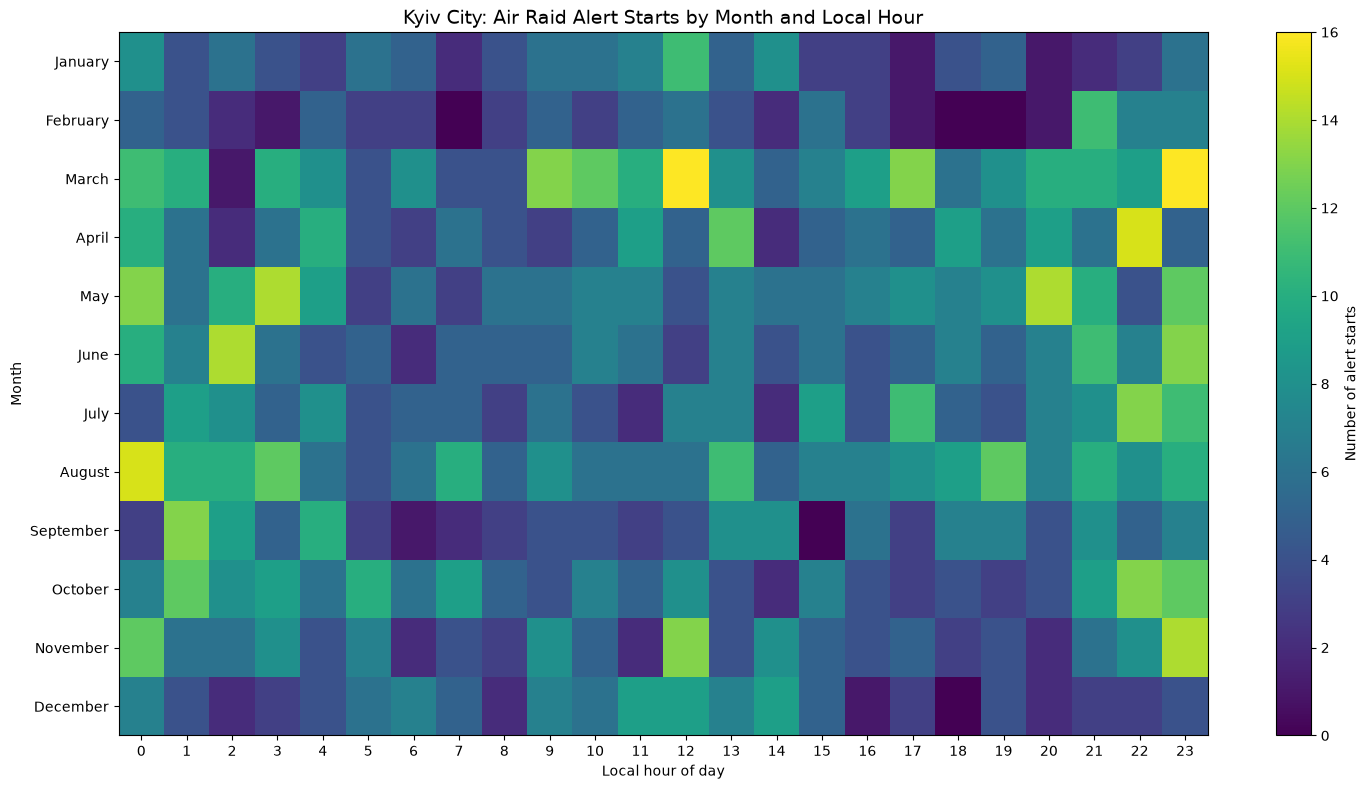


✅ Figure saved successfully:
D:\it10\PythonProject2\reports\figures\04_kyiv_city_alert_starts_month_hour_heatmap.png

✅ Kyiv City month-hour heatmap was created successfully.


In [10]:
# =====================================================================
# Heatmap of air raid alert starts in Kyiv City:
# month of year × local hour of day
# =====================================================================

import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import config

importlib.reload(config)

CLEANED_ALERTS_FILE = config.CLEANED_ALERTS_FILE
FIGURES_DIR = config.FIGURES_DIR
FORECAST_REGION = config.FORECAST_REGION
ANALYSIS_TIMEZONE = config.ANALYSIS_TIMEZONE


# ---------------------------------------------------------------------
# 1. Load cleaned event-level data
# ---------------------------------------------------------------------

print("=" * 78)
print("KYIV CITY ALERT-START HEATMAP")
print("=" * 78)

if not CLEANED_ALERTS_FILE.exists():
    raise FileNotFoundError(
        "The cleaned event-level CSV was not found.\n"
        f"Expected file: {CLEANED_ALERTS_FILE}"
    )

cleaned_events_heatmap = pd.read_csv(
    CLEANED_ALERTS_FILE,
)

required_columns = [
    "region",
    "started_at_local",
]

missing_columns = [
    column
    for column in required_columns
    if column not in cleaned_events_heatmap.columns
]

if missing_columns:
    raise KeyError(
        "The cleaned dataset is missing required columns:\n"
        f"{missing_columns}\n\n"
        f"Available columns:\n"
        f"{cleaned_events_heatmap.columns.tolist()}"
    )


# ---------------------------------------------------------------------
# 2. Restore local Kyiv timestamps correctly
# ---------------------------------------------------------------------

# Convert strings to UTC first, then explicitly convert to Europe/Kyiv.
# This avoids problems caused by different UTC offsets before and after
# daylight-saving time changes.
cleaned_events_heatmap["started_at_local"] = (
    pd.to_datetime(
        cleaned_events_heatmap["started_at_local"],
        utc=True,
        errors="coerce",
    )
    .dt.tz_convert(ANALYSIS_TIMEZONE)
)

invalid_start_count = int(
    cleaned_events_heatmap["started_at_local"].isna().sum()
)

if invalid_start_count > 0:
    raise ValueError(
        "Some start timestamps could not be parsed correctly. "
        f"Invalid timestamp count: {invalid_start_count}"
    )


# ---------------------------------------------------------------------
# 3. Keep only Kyiv City events
# ---------------------------------------------------------------------

kyiv_events = (
    cleaned_events_heatmap.loc[
        cleaned_events_heatmap["region"].eq(FORECAST_REGION)
    ]
    .copy()
)

if kyiv_events.empty:
    raise ValueError(
        f"No events were found for forecast region: {FORECAST_REGION}"
    )

kyiv_events["month_number"] = (
    kyiv_events["started_at_local"]
    .dt.month
)

kyiv_events["hour"] = (
    kyiv_events["started_at_local"]
    .dt.hour
)

print(f"Forecast region: {FORECAST_REGION}")
print(f"Kyiv City events: {len(kyiv_events):,}")
print(
    "Time range: "
    f"{kyiv_events['started_at_local'].min()} "
    f"to {kyiv_events['started_at_local'].max()}"
)


# ---------------------------------------------------------------------
# 4. Count alert starts for every month-hour combination
# ---------------------------------------------------------------------

month_hour_counts = pd.crosstab(
    kyiv_events["month_number"],
    kyiv_events["hour"],
)

month_hour_counts = (
    month_hour_counts
    .reindex(
        index=range(1, 13),
        columns=range(0, 24),
        fill_value=0,
    )
)

month_labels = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

month_hour_counts.index = month_labels
month_hour_counts.columns.name = "Hour of day"

print("\nMonth-hour table shape:")
print(month_hour_counts.shape)

print("\nAlert-start counts by month:")
display(
    month_hour_counts
    .sum(axis=1)
    .rename("alert_start_count")
    .to_frame()
)


# ---------------------------------------------------------------------
# 5. Create heatmap
# ---------------------------------------------------------------------

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

figure_path = (
    FIGURES_DIR
    / "04_kyiv_city_alert_starts_month_hour_heatmap.png"
)

figure, axes = plt.subplots(
    figsize=(15, 8),
)

heatmap = axes.imshow(
    month_hour_counts.to_numpy(),
    aspect="auto",
)

colorbar = figure.colorbar(
    heatmap,
    ax=axes,
)

colorbar.set_label(
    "Number of alert starts",
)

axes.set_title(
    "Kyiv City: Air Raid Alert Starts by Month and Local Hour",
    fontsize=14,
)

axes.set_xlabel(
    "Local hour of day",
)

axes.set_ylabel(
    "Month",
)

axes.set_xticks(
    np.arange(24),
)

axes.set_xticklabels(
    range(24),
)

axes.set_yticks(
    np.arange(12),
)

axes.set_yticklabels(
    month_labels,
)

figure.tight_layout()

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("\n✅ Figure saved successfully:")
print(figure_path)


# ---------------------------------------------------------------------
# 6. Final checks
# ---------------------------------------------------------------------

assert month_hour_counts.shape == (12, 24)

assert int(month_hour_counts.to_numpy().sum()) == len(
    kyiv_events
)

assert figure_path.exists()

print("\n✅ Kyiv City month-hour heatmap was created successfully.")

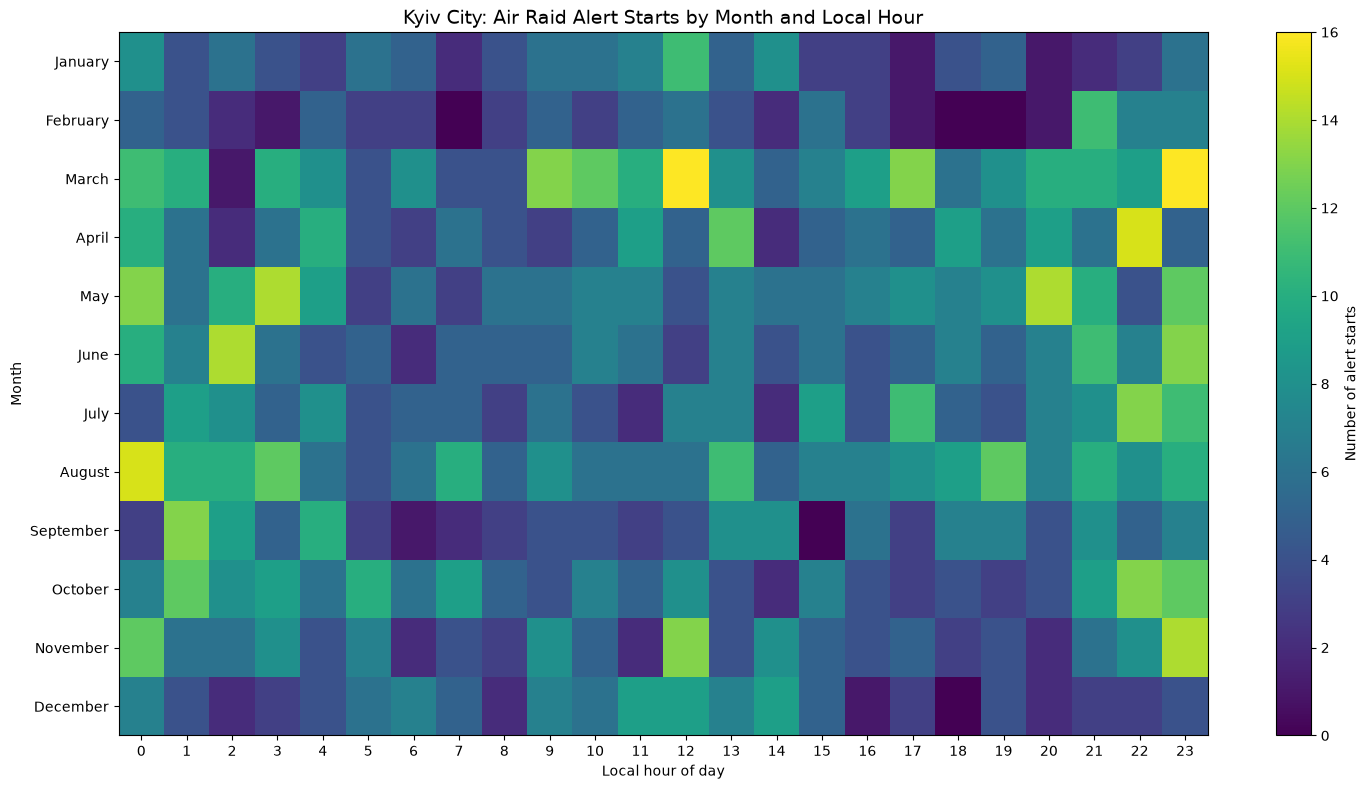

REUSABLE KYIV CITY MONTH-HOUR HEATMAP RESULT
Forecast region: Kyiv City
Kyiv City events: 1,795
Month-hour table shape: (12, 24)

Alert starts by month:


,alert_start_count
month,
January,113
February,87
March,212
April,153
May,183
June,155
July,151
August,198
September,127



Files created:
  D:\it10\PythonProject2\data\processed\kyiv_city_alert_starts_month_hour.csv
  D:\it10\PythonProject2\reports\figures\04_kyiv_city_alert_starts_month_hour_heatmap.png

✅ Reusable Kyiv City month-hour heatmap works correctly.


In [11]:
# =====================================================================
# Reusable Kyiv City month-hour alert-start heatmap
# =====================================================================

import importlib

import matplotlib.pyplot as plt
import pandas as pd

import config
import visualization

importlib.reload(config)
importlib.reload(visualization)

from visualization import (
    plot_alert_start_month_hour_heatmap,
    prepare_month_hour_alert_start_counts,
)


# ---------------------------------------------------------------------
# Refresh configuration and load cleaned event-level data
# ---------------------------------------------------------------------

CLEANED_ALERTS_FILE = config.CLEANED_ALERTS_FILE
PROCESSED_DATA_DIR = config.PROCESSED_DATA_DIR
FIGURES_DIR = config.FIGURES_DIR
FORECAST_REGION = config.FORECAST_REGION
ANALYSIS_TIMEZONE = config.ANALYSIS_TIMEZONE

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

cleaned_events_heatmap_script = pd.read_csv(
    CLEANED_ALERTS_FILE,
)


# ---------------------------------------------------------------------
# Create month-hour counts with reusable function
# ---------------------------------------------------------------------

month_hour_counts_script, kyiv_event_count = (
    prepare_month_hour_alert_start_counts(
        cleaned_events=cleaned_events_heatmap_script,
        region=FORECAST_REGION,
        analysis_timezone=ANALYSIS_TIMEZONE,
    )
)

heatmap_table_path = (
    PROCESSED_DATA_DIR
    / "kyiv_city_alert_starts_month_hour.csv"
)

heatmap_figure_path = (
    FIGURES_DIR
    / "04_kyiv_city_alert_starts_month_hour_heatmap.png"
)

month_hour_counts_script.to_csv(
    heatmap_table_path,
)


# ---------------------------------------------------------------------
# Create and save the reusable figure
# ---------------------------------------------------------------------

figure, axes = plot_alert_start_month_hour_heatmap(
    month_hour_counts=month_hour_counts_script,
    region=FORECAST_REGION,
    output_path=heatmap_figure_path,
)

plt.show()


# ---------------------------------------------------------------------
# Validation and output
# ---------------------------------------------------------------------

print("=" * 78)
print("REUSABLE KYIV CITY MONTH-HOUR HEATMAP RESULT")
print("=" * 78)

print(f"Forecast region: {FORECAST_REGION}")
print(f"Kyiv City events: {kyiv_event_count:,}")
print(f"Month-hour table shape: {month_hour_counts_script.shape}")

print("\nAlert starts by month:")
display(
    month_hour_counts_script
    .sum(axis=1)
    .rename("alert_start_count")
    .to_frame()
)

assert month_hour_counts_script.shape == (12, 24)

assert int(
    month_hour_counts_script.to_numpy().sum()
) == kyiv_event_count

assert heatmap_table_path.exists()
assert heatmap_figure_path.exists()

print("\nFiles created:")
print(f"  {heatmap_table_path}")
print(f"  {heatmap_figure_path}")

print("\n✅ Reusable Kyiv City month-hour heatmap works correctly.")

DAILY ALERT-DURATION CORRELATION HEATMAP
Selected daily rows: 6,785
Regions included: 5
Date range: 2022-03-15 to 2025-11-30

Daily duration matrix shape:
(1357, 5)

Daily observations per region:


,daily_observations
region,
Kyiv City,1357
Lvivska oblast,1357
Odeska oblast,1357
Kharkivska oblast,1357
Dnipropetrovska oblast,1357



Correlation matrix:


region,Kyiv City,Lvivska oblast,Odeska oblast,Kharkivska oblast,Dnipropetrovska oblast
region,,,,,
Kyiv City,1.000,0.551,0.387,0.223,0.318
Lvivska oblast,0.551,1.000,0.522,0.127,0.254
Odeska oblast,0.387,0.522,1.000,0.283,0.385
Kharkivska oblast,0.223,0.127,0.283,1.000,0.561
Dnipropetrovska oblast,0.318,0.254,0.385,0.561,1.000


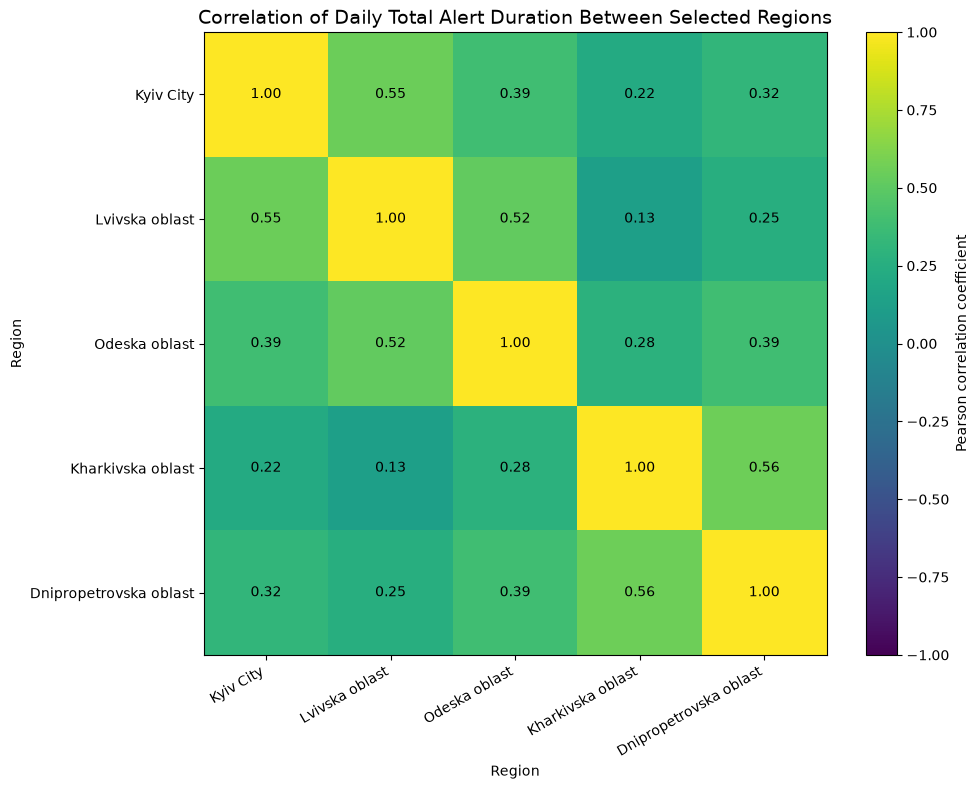


✅ Figure saved successfully:
D:\it10\PythonProject2\reports\figures\05_selected_regions_daily_duration_correlation_heatmap.png

✅ Daily duration correlation heatmap was created successfully.


In [13]:
# =====================================================================
# Correlation heatmap:
# daily total alert duration between selected regions
# =====================================================================

import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import config

importlib.reload(config)

SELECTED_REGIONS = config.SELECTED_REGIONS
FIGURES_DIR = config.FIGURES_DIR


# ---------------------------------------------------------------------
# 1. Validate daily metrics
# ---------------------------------------------------------------------

print("=" * 78)
print("DAILY ALERT-DURATION CORRELATION HEATMAP")
print("=" * 78)

required_columns = [
    "date",
    "region",
    "total_duration_min",
]

missing_columns = [
    column
    for column in required_columns
    if column not in daily_metrics.columns
]

if missing_columns:
    raise KeyError(
        "The daily metrics DataFrame is missing required columns:\n"
        f"{missing_columns}\n\n"
        f"Available columns:\n{daily_metrics.columns.tolist()}"
    )

selected_daily_metrics = (
    daily_metrics.loc[
        daily_metrics["region"].isin(SELECTED_REGIONS),
        ["date", "region", "total_duration_min"],
    ]
    .copy()
)

missing_regions = [
    region
    for region in SELECTED_REGIONS
    if region not in selected_daily_metrics["region"].unique()
]

if missing_regions:
    raise ValueError(
        "Some selected regions are absent from daily metrics:\n"
        f"{missing_regions}"
    )

duplicate_date_region_rows = int(
    selected_daily_metrics.duplicated(
        subset=["date", "region"]
    ).sum()
)

if duplicate_date_region_rows > 0:
    raise ValueError(
        "Duplicate date-region rows were found. "
        f"Duplicate count: {duplicate_date_region_rows}"
    )

print(f"Selected daily rows: {len(selected_daily_metrics):,}")
print(
    f"Regions included: "
    f"{selected_daily_metrics['region'].nunique()}"
)
print(
    f"Date range: "
    f"{selected_daily_metrics['date'].min().date()} "
    f"to {selected_daily_metrics['date'].max().date()}"
)


# ---------------------------------------------------------------------
# 2. Create date × region matrix
# ---------------------------------------------------------------------

daily_duration_matrix = (
    selected_daily_metrics
    .pivot(
        index="date",
        columns="region",
        values="total_duration_min",
    )
    .reindex(columns=SELECTED_REGIONS)
    .sort_index()
)

missing_values_by_region = (
    daily_duration_matrix
    .isna()
    .sum()
)

if missing_values_by_region.any():
    raise ValueError(
        "Missing daily values were found after pivoting:\n"
        f"{missing_values_by_region[missing_values_by_region > 0]}"
    )

print("\nDaily duration matrix shape:")
print(daily_duration_matrix.shape)

print("\nDaily observations per region:")
display(
    daily_duration_matrix
    .count()
    .rename("daily_observations")
    .to_frame()
)


# ---------------------------------------------------------------------
# 3. Calculate Pearson correlation matrix
# ---------------------------------------------------------------------

correlation_matrix = daily_duration_matrix.corr(
    method="pearson"
)

print("\nCorrelation matrix:")
display(correlation_matrix.round(3))


# ---------------------------------------------------------------------
# 4. Create heatmap
# ---------------------------------------------------------------------

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

figure_path = (
    FIGURES_DIR
    / "05_selected_regions_daily_duration_correlation_heatmap.png"
)

figure, axes = plt.subplots(
    figsize=(10, 8),
)

heatmap = axes.imshow(
    correlation_matrix.to_numpy(),
    vmin=-1,
    vmax=1,
    aspect="equal",
)

colorbar = figure.colorbar(
    heatmap,
    ax=axes,
)

colorbar.set_label(
    "Pearson correlation coefficient",
)

axes.set_title(
    "Correlation of Daily Total Alert Duration Between Selected Regions",
    fontsize=14,
)

axes.set_xlabel("Region")
axes.set_ylabel("Region")

axes.set_xticks(
    np.arange(len(SELECTED_REGIONS))
)

axes.set_xticklabels(
    SELECTED_REGIONS,
    rotation=30,
    ha="right",
)

axes.set_yticks(
    np.arange(len(SELECTED_REGIONS))
)

axes.set_yticklabels(
    SELECTED_REGIONS,
)

# Add numerical values inside heatmap cells.
for row_index in range(len(SELECTED_REGIONS)):
    for column_index in range(len(SELECTED_REGIONS)):
        correlation_value = correlation_matrix.iloc[
            row_index,
            column_index,
        ]

        axes.text(
            column_index,
            row_index,
            f"{correlation_value:.2f}",
            ha="center",
            va="center",
            fontsize=10,
        )

figure.tight_layout()

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("\n✅ Figure saved successfully:")
print(figure_path)


# ---------------------------------------------------------------------
# 5. Final checks
# ---------------------------------------------------------------------

expected_shape = (
    len(SELECTED_REGIONS),
    len(SELECTED_REGIONS),
)

assert correlation_matrix.shape == expected_shape

assert np.allclose(
    correlation_matrix.to_numpy(),
    correlation_matrix.to_numpy().T,
)

assert np.allclose(
    np.diag(correlation_matrix.to_numpy()),
    np.ones(len(SELECTED_REGIONS)),
)

assert figure_path.exists()

print(
    "\n✅ Daily duration correlation heatmap was created successfully."
)

,period,start_date,end_date,days
0,Training period,2022-03-15,2025-06-03,1177
1,Test period,2025-06-04,2025-11-30,180


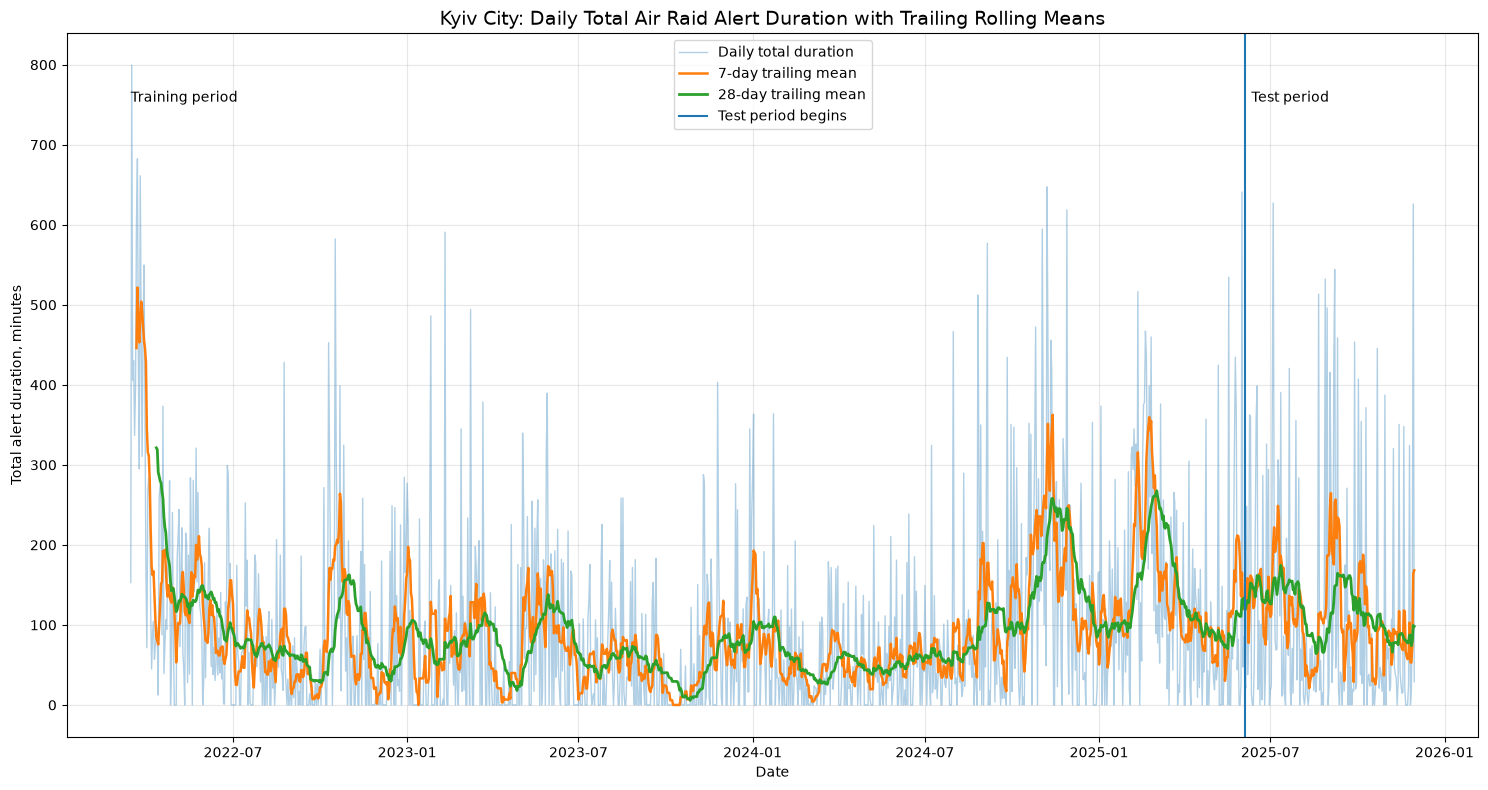

✅ Daily time-series chart was created successfully.
Saved to: D:\it10\PythonProject2\reports\figures\08_kyiv_city_daily_duration_with_rolling_means.png


In [2]:
# =====================================================================
# Kyiv City daily time series:
# daily duration, rolling means and train/test boundary
# =====================================================================

import matplotlib.pyplot as plt
import pandas as pd

import config


# ---------------------------------------------------------------------
# 1. Read the forecast test period to find its first date
# ---------------------------------------------------------------------

FORECAST_REGION = config.FORECAST_REGION
FORECAST_TEST_FILE = config.FORECAST_TEST_FILE
FIGURES_DIR = config.FIGURES_DIR

forecast_test_data = pd.read_csv(
    FORECAST_TEST_FILE,
    parse_dates=["date"],
)

test_start_date = forecast_test_data["date"].min()


# ---------------------------------------------------------------------
# 2. Select the full daily time series for Kyiv City
# ---------------------------------------------------------------------

kyiv_daily_series = (
    daily_metrics.loc[
        daily_metrics["region"].eq(FORECAST_REGION),
        ["date", "total_duration_min"],
    ]
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

if kyiv_daily_series.empty:
    raise ValueError(
        f"No daily observations found for: {FORECAST_REGION}"
    )

kyiv_daily_series["date"] = pd.to_datetime(
    kyiv_daily_series["date"]
)

if kyiv_daily_series["date"].duplicated().any():
    raise ValueError(
        "Duplicate dates were found in the Kyiv City daily series."
    )


# ---------------------------------------------------------------------
# 3. Calculate trailing rolling means
# ---------------------------------------------------------------------

# These means use the current day and previous days.
kyiv_daily_series["rolling_mean_7"] = (
    kyiv_daily_series["total_duration_min"]
    .rolling(window=7, min_periods=7)
    .mean()
)

kyiv_daily_series["rolling_mean_28"] = (
    kyiv_daily_series["total_duration_min"]
    .rolling(window=28, min_periods=28)
    .mean()
)


# ---------------------------------------------------------------------
# 4. Save a short summary table
# ---------------------------------------------------------------------

period_summary = pd.DataFrame(
    {
        "period": ["Training period", "Test period"],
        "start_date": [
            kyiv_daily_series["date"].min().date(),
            test_start_date.date(),
        ],
        "end_date": [
            (
                test_start_date
                - pd.Timedelta(days=1)
            ).date(),
            kyiv_daily_series["date"].max().date(),
        ],
        "days": [
            int(
                kyiv_daily_series["date"]
                .lt(test_start_date)
                .sum()
            ),
            int(
                kyiv_daily_series["date"]
                .ge(test_start_date)
                .sum()
            ),
        ],
    }
)

display(period_summary)


# ---------------------------------------------------------------------
# 5. Create the main daily time-series chart
# ---------------------------------------------------------------------

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

figure_path = (
    FIGURES_DIR
    / "08_kyiv_city_daily_duration_with_rolling_means.png"
)

figure, axes = plt.subplots(
    figsize=(15, 8)
)

axes.plot(
    kyiv_daily_series["date"],
    kyiv_daily_series["total_duration_min"],
    label="Daily total duration",
    alpha=0.35,
    linewidth=1,
)

axes.plot(
    kyiv_daily_series["date"],
    kyiv_daily_series["rolling_mean_7"],
    label="7-day trailing mean",
    linewidth=1.8,
)

axes.plot(
    kyiv_daily_series["date"],
    kyiv_daily_series["rolling_mean_28"],
    label="28-day trailing mean",
    linewidth=2,
)

axes.axvline(
    test_start_date,
    label="Test period begins",
    linewidth=1.5,
)

maximum_duration = kyiv_daily_series[
    "total_duration_min"
].max()

axes.text(
    kyiv_daily_series["date"].min(),
    maximum_duration * 0.96,
    "Training period",
    ha="left",
    va="top",
)

axes.text(
    test_start_date + pd.Timedelta(days=7),
    maximum_duration * 0.96,
    "Test period",
    ha="left",
    va="top",
)

axes.set_title(
    "Kyiv City: Daily Total Air Raid Alert Duration "
    "with Trailing Rolling Means",
    fontsize=14,
)

axes.set_xlabel("Date")
axes.set_ylabel("Total alert duration, minutes")

axes.grid(
    True,
    alpha=0.3,
)

axes.legend()

figure.tight_layout()

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------------------
# 6. Final check
# ---------------------------------------------------------------------

assert figure_path.exists()

print("✅ Daily time-series chart was created successfully.")
print(f"Saved to: {figure_path}")

KYIV CITY: TRAIN-ONLY ACF/PACF LAG DIAGNOSTICS
Training observations: 1,177
Training period: 2022-03-15 to 2025-06-03
Final test period begins: 2025-06-04
Maximum analysed lag: 60 days

Forecast-related lag values:


,lag_days,acf,acf_significant_95,pacf,pacf_significant_95
1,1,0.327,True,0.327,True
7,7,0.266,True,0.116,True
14,14,0.152,True,0.002,False


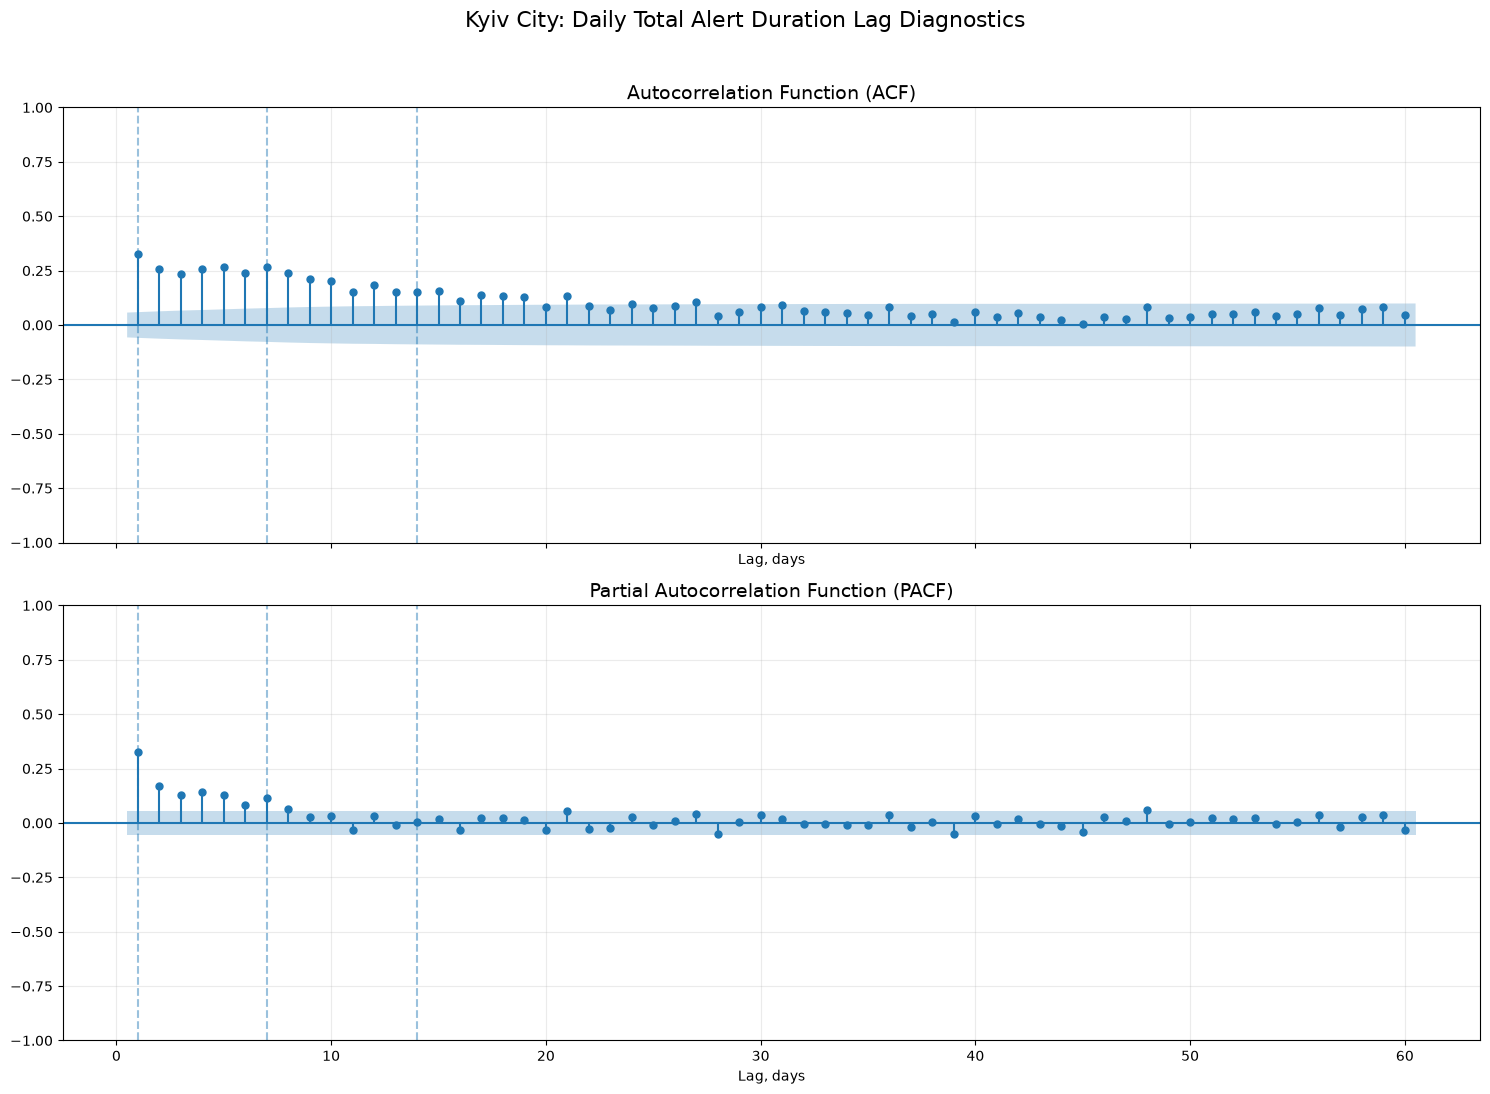


✅ Reusable ACF/PACF analysis completed successfully.
Diagnostics table: D:\it10\PythonProject2\data\processed\kyiv_city_acf_pacf_lags.csv
Figure: D:\it10\PythonProject2\reports\figures\09_kyiv_city_acf_pacf_lags.png


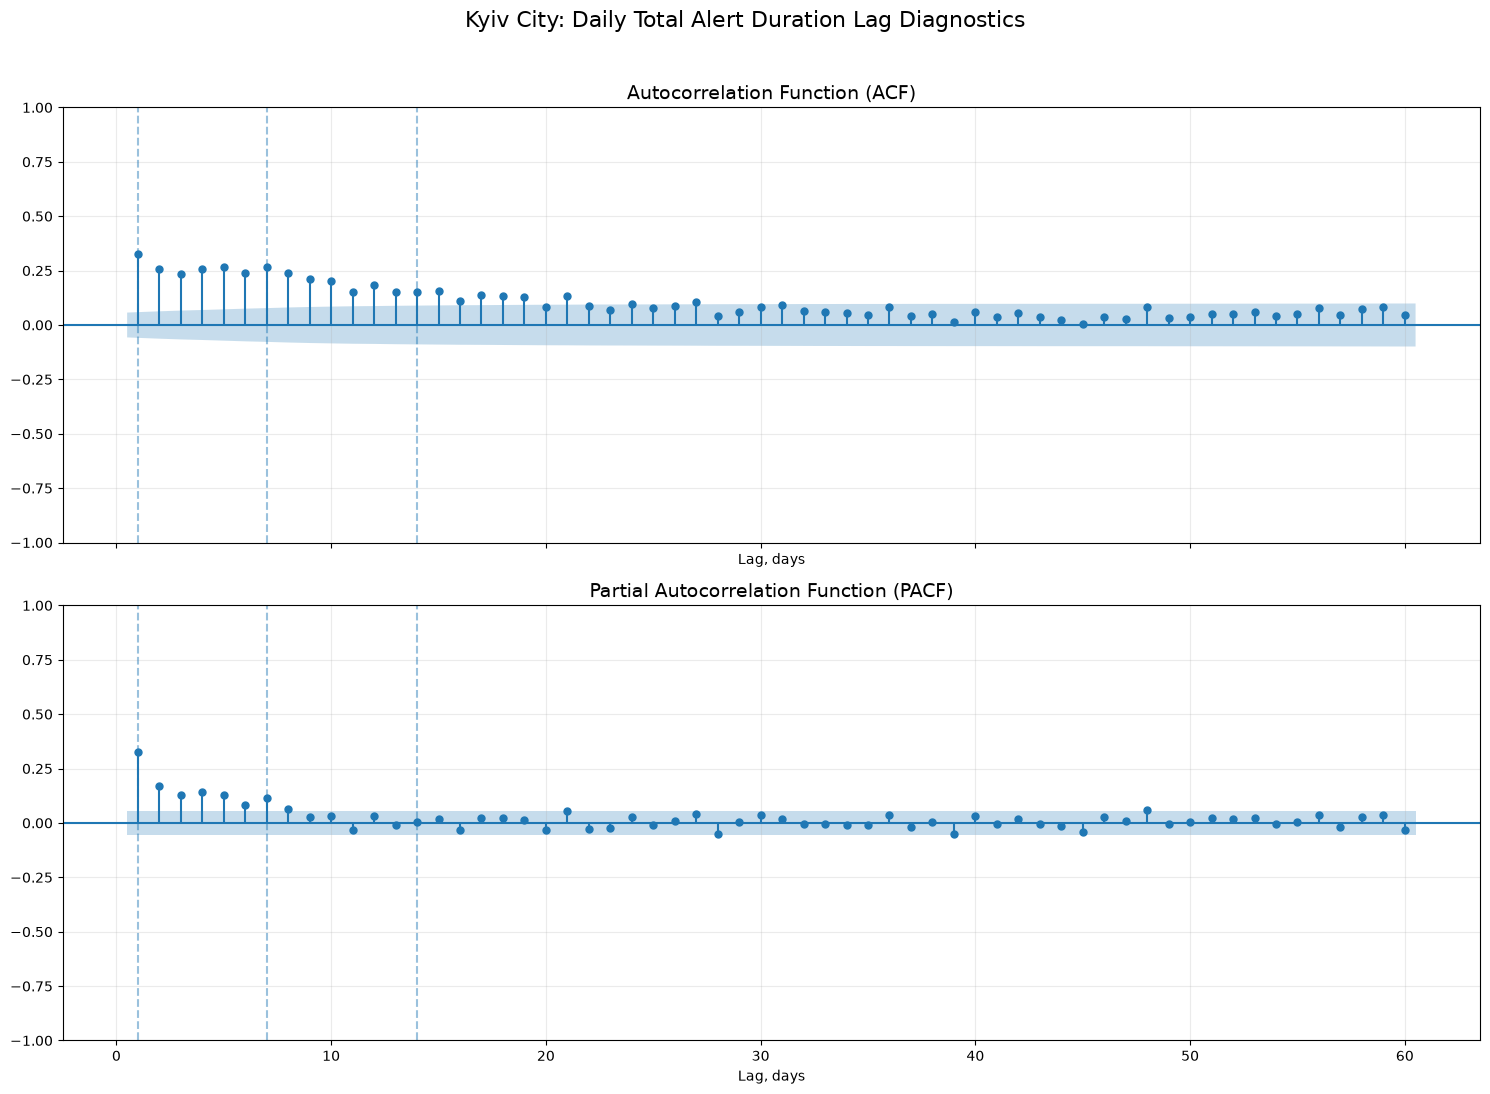

In [5]:
# =====================================================================
# Reusable ACF/PACF lag diagnostics for Kyiv City
# =====================================================================

import importlib

import pandas as pd
from IPython.display import display

import config
import visualization

importlib.reload(config)
importlib.reload(visualization)

from visualization import (
    plot_acf_pacf_lag_diagnostics,
    prepare_acf_pacf_lag_diagnostics,
)


# ---------------------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------------------

FORECAST_REGION = config.FORECAST_REGION
FORECAST_TEST_FILE = config.FORECAST_TEST_FILE

ACF_PACF_LAGS_FILE = config.KYIV_CITY_ACF_PACF_LAGS_FILE
ACF_PACF_FIGURE = config.KYIV_CITY_ACF_PACF_FIGURE

MAX_LAGS = 60
SELECTED_LAGS = [1, 7, 14]


# ---------------------------------------------------------------------
# 2. Read the test start date
# ---------------------------------------------------------------------

forecast_test_data = pd.read_csv(
    FORECAST_TEST_FILE,
    parse_dates=["date"],
)

test_start_date = forecast_test_data["date"].min()

if pd.isna(test_start_date):
    raise ValueError(
        "Could not determine the start of the final test period."
    )


# ---------------------------------------------------------------------
# 3. Prepare train-only ACF/PACF diagnostics
# ---------------------------------------------------------------------

(
    training_series,
    lag_diagnostics,
) = prepare_acf_pacf_lag_diagnostics(
    daily_metrics=daily_metrics,
    forecast_region=FORECAST_REGION,
    test_start_date=test_start_date,
    max_lags=MAX_LAGS,
)

ACF_PACF_LAGS_FILE.parent.mkdir(
    parents=True,
    exist_ok=True,
)

lag_diagnostics.to_csv(
    ACF_PACF_LAGS_FILE,
    index=False,
)


# ---------------------------------------------------------------------
# 4. Show values for forecast-related lags
# ---------------------------------------------------------------------

selected_lag_summary = (
    lag_diagnostics.loc[
        lag_diagnostics["lag_days"].isin(SELECTED_LAGS),
        [
            "lag_days",
            "acf",
            "acf_significant_95",
            "pacf",
            "pacf_significant_95",
        ],
    ]
    .copy()
)

print("=" * 78)
print("KYIV CITY: TRAIN-ONLY ACF/PACF LAG DIAGNOSTICS")
print("=" * 78)

print(f"Training observations: {len(training_series):,}")

print(
    "Training period: "
    f"{training_series['date'].min().date()} "
    f"to {training_series['date'].max().date()}"
)

print(f"Final test period begins: {test_start_date.date()}")
print(f"Maximum analysed lag: {MAX_LAGS} days")

print("\nForecast-related lag values:")
display(selected_lag_summary.round(3))


# ---------------------------------------------------------------------
# 5. Create and save ACF/PACF figure
# ---------------------------------------------------------------------

figure, axes = plot_acf_pacf_lag_diagnostics(
    training_series=training_series,
    max_lags=MAX_LAGS,
    selected_lags=SELECTED_LAGS,
    output_path=ACF_PACF_FIGURE,
)

display(figure)


# ---------------------------------------------------------------------
# 6. Final validation
# ---------------------------------------------------------------------

assert len(lag_diagnostics) == MAX_LAGS + 1

assert set(SELECTED_LAGS).issubset(
    set(lag_diagnostics["lag_days"])
)

assert ACF_PACF_LAGS_FILE.exists()
assert ACF_PACF_FIGURE.exists()

print("\n✅ Reusable ACF/PACF analysis completed successfully.")
print(f"Diagnostics table: {ACF_PACF_LAGS_FILE}")
print(f"Figure: {ACF_PACF_FIGURE}")

## Interpretation of ACF/PACF lag diagnostics

The ACF/PACF analysis was calculated using only the training period, from 2022-03-15 to 2025-06-03. The final 180-day test period was excluded to avoid using future observations when justifying forecasting features.

The daily total alert duration in Kyiv City has meaningful temporal dependence:

* **Lag 1:** ACF = 0.327 and PACF = 0.327. The duration on the previous day has a direct and statistically significant relationship with the next day. Therefore, `lag_1` is a justified forecasting feature.
* **Lag 7:** ACF = 0.266 and PACF = 0.116. The significant partial autocorrelation at seven days indicates a moderate weekly pattern that remains after accounting for shorter lags. This supports using `lag_7`, a 7-day rolling mean, and the Seasonal Naive baseline `ŷₜ = yₜ₋₇`.
* **Lag 14:** ACF = 0.152 is statistically significant, but PACF = 0.002 is not significant. This suggests that the 14-day relationship is mainly indirect and may be explained by shorter lags and weekly structure. The feature is retained in Ridge Regression, where regularization can reduce its influence if it adds little predictive value.

Overall, the diagnostics show that the Kyiv City daily alert-duration series is not independent over time. Previous days, especially the preceding day and the same weekday one week earlier, contain useful information for one-step-ahead forecasting.

These results describe historical statistical dependence only. They do not imply a stable causal rule, because air raid alerts are affected by changing military and political conditions that are not included in the dataset.


KYIV CITY: TRAIN-ONLY WEEKDAY PATTERN
Training period: 2022-03-15 to 2025-06-03
Final test period begins: 2025-06-04
Training observations: 1,177

Daily total alert duration by weekday:


,weekday,days,mean_duration_min,median_duration_min,std_duration_min,min_duration_min,max_duration_min,zero_duration_days,zero_duration_share_percent
0,Monday,168,94.65,42.28,128.38,0.0,600.65,58,34.52
1,Tuesday,169,88.76,45.25,119.27,0.0,682.52,53,31.36
2,Wednesday,168,96.12,53.13,120.47,0.0,799.53,46,27.38
3,Thursday,168,105.23,65.10,128.48,0.0,647.42,51,30.36
4,Friday,168,94.14,63.05,112.21,0.0,661.18,40,23.81
5,Saturday,168,88.09,46.71,111.74,0.0,594.75,56,33.33
6,Sunday,168,87.51,32.98,118.25,0.0,641.03,68,40.48


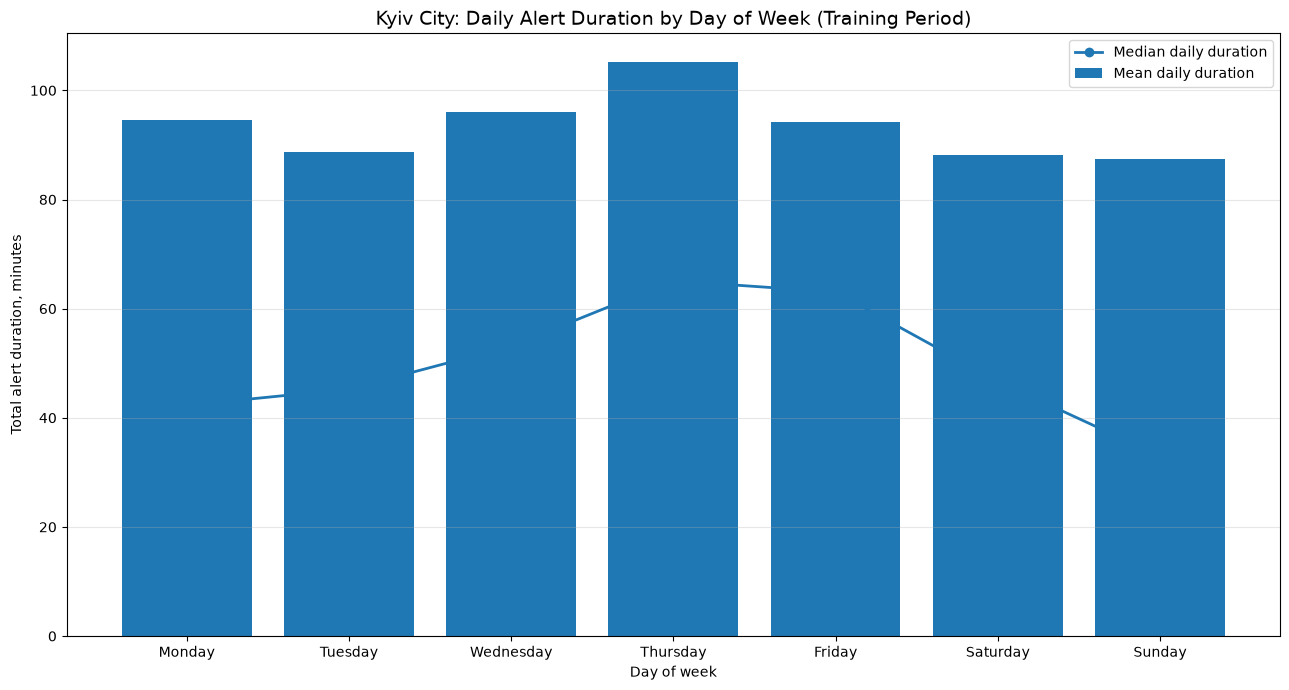


✅ Reusable weekday-pattern analysis completed successfully.
Table: D:\it10\PythonProject2\data\processed\kyiv_city_weekday_pattern.csv
Figure: D:\it10\PythonProject2\reports\figures\10_kyiv_city_weekday_pattern.png


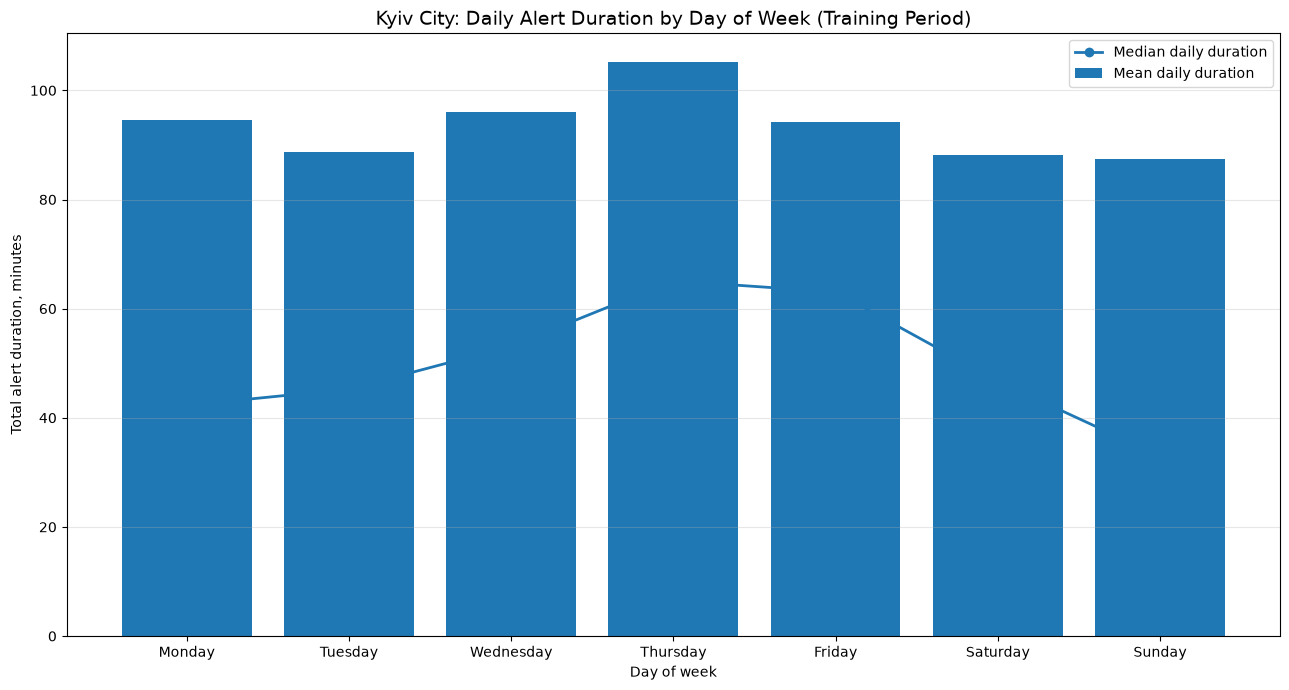

In [7]:
# =====================================================================
# Reusable weekday-pattern analysis for Kyiv City
# =====================================================================

import importlib

import pandas as pd
from IPython.display import display

import config
import visualization

importlib.reload(config)
importlib.reload(visualization)

from visualization import (
    plot_weekday_pattern,
    prepare_weekday_pattern,
)


# ---------------------------------------------------------------------
# 1. Configuration and test-period boundary
# ---------------------------------------------------------------------

FORECAST_REGION = config.FORECAST_REGION
FORECAST_TEST_FILE = config.FORECAST_TEST_FILE

WEEKDAY_PATTERN_FILE = config.KYIV_CITY_WEEKDAY_PATTERN_FILE
WEEKDAY_PATTERN_FIGURE = config.KYIV_CITY_WEEKDAY_PATTERN_FIGURE

forecast_test_data = pd.read_csv(
    FORECAST_TEST_FILE,
    parse_dates=["date"],
)

test_start_date = forecast_test_data["date"].min()

if pd.isna(test_start_date):
    raise ValueError(
        "Could not determine the start of the final test period."
    )


# ---------------------------------------------------------------------
# 2. Prepare train-only weekday statistics
# ---------------------------------------------------------------------

(
    training_weekday_data,
    weekday_summary,
) = prepare_weekday_pattern(
    daily_metrics=daily_metrics,
    forecast_region=FORECAST_REGION,
    test_start_date=test_start_date,
)

WEEKDAY_PATTERN_FILE.parent.mkdir(
    parents=True,
    exist_ok=True,
)

weekday_summary.to_csv(
    WEEKDAY_PATTERN_FILE,
    index=False,
)


# ---------------------------------------------------------------------
# 3. Display the weekday table
# ---------------------------------------------------------------------

print("=" * 78)
print("KYIV CITY: TRAIN-ONLY WEEKDAY PATTERN")
print("=" * 78)

print(
    "Training period: "
    f"{training_weekday_data['date'].min().date()} "
    f"to {training_weekday_data['date'].max().date()}"
)

print(f"Final test period begins: {test_start_date.date()}")
print(f"Training observations: {len(training_weekday_data):,}")

print("\nDaily total alert duration by weekday:")
display(weekday_summary.round(2))


# ---------------------------------------------------------------------
# 4. Create and save the figure
# ---------------------------------------------------------------------

figure, axes = plot_weekday_pattern(
    weekday_summary=weekday_summary,
    forecast_region=FORECAST_REGION,
    output_path=WEEKDAY_PATTERN_FIGURE,
)

display(figure)


# ---------------------------------------------------------------------
# 5. Final validation
# ---------------------------------------------------------------------

assert weekday_summary["days"].sum() == len(
    training_weekday_data
)

assert weekday_summary["weekday"].tolist() == [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

assert WEEKDAY_PATTERN_FILE.exists()
assert WEEKDAY_PATTERN_FIGURE.exists()

print("\n✅ Reusable weekday-pattern analysis completed successfully.")
print(f"Table: {WEEKDAY_PATTERN_FILE}")
print(f"Figure: {WEEKDAY_PATTERN_FIGURE}")

## Interpretation of the weekday pattern

The weekday analysis was calculated using only the training period, from 2022-03-15 to 2025-06-03. The final 180-day test period was excluded so that calendar-feature justification does not use future observations.

The results indicate a moderate weekly pattern in the Kyiv City daily alert-duration series:

* **Thursday** has the highest mean daily duration, 105.23 minutes, and the highest median duration, 65.10 minutes.
* **Sunday** has the lowest median duration, 32.98 minutes, and the largest share of zero-duration days: 68 out of 168 days, or approximately 40.5%.
* **Friday** has the smallest number of zero-duration days: 40 out of 168 days, or approximately 23.8%.
* The mean daily duration varies from 87.51 to 105.23 minutes across weekdays. However, standard deviations are large for every weekday, approximately 112–128 minutes.

Therefore, day-of-week information provides a useful but secondary forecasting signal. The weekday pattern is not strong enough to imply a fixed weekly schedule of alerts. Instead, it supports the use of calendar features such as `day_of_week`, `is_weekend`, `day_of_week_sin`, and `day_of_week_cos` together with stronger temporal features such as `lag_1` and `lag_7`.

The consistent difference between mean and median duration also indicates a right-skewed distribution: occasional very long alert days substantially increase the mean. For this reason, both mean and median values are reported.

These results describe historical statistical patterns only. They do not establish a causal relationship between the day of week and air raid alerts.
